In [98]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# Proposed model

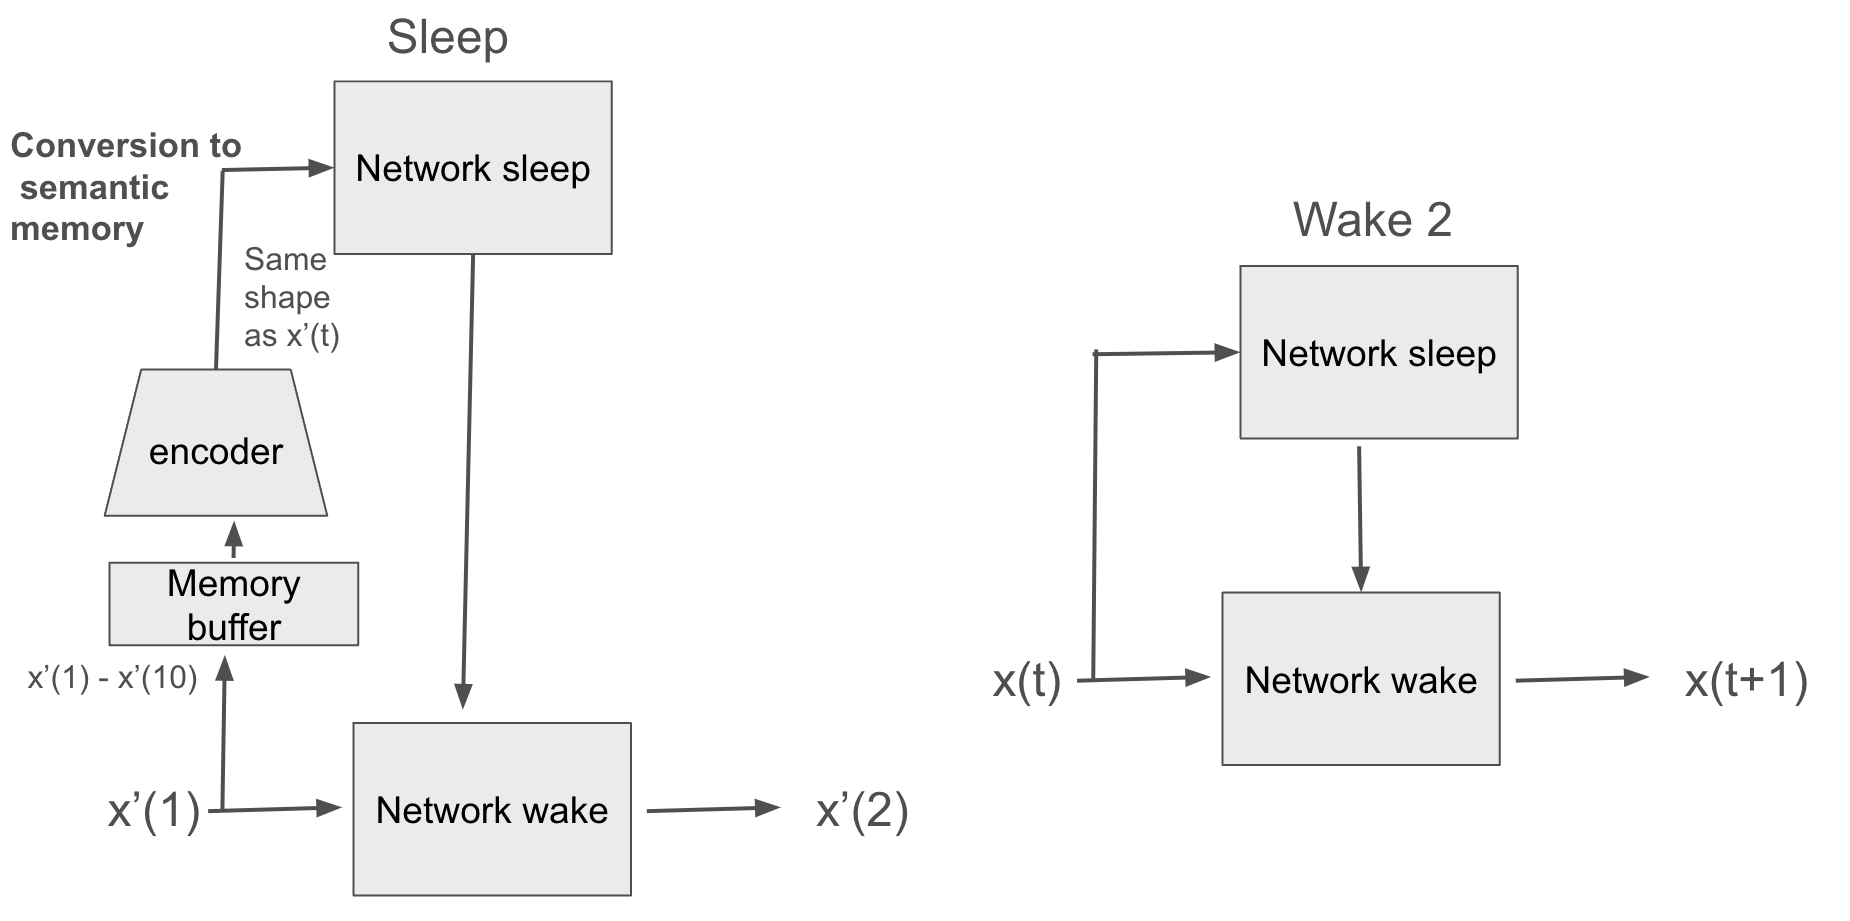

## Experiment 2:
### Observation: During sleep Hippocampus feeds compressed data to Neo-cortex.

### Hypothesis: Distributing learning to Neo-cortex in compressed form improves performance.






In [99]:
def _get_member(community, n_members, clockwise=True):
    seq = chr(community*n_members + ord('A'))
    
    if clockwise:
        next_token = chr(community*n_members + ord('A') + 1)
    else:
        next_token = chr(community*n_members + ord('A') + n_members-1)

    for _ in range(n_members-1):
        seq += next_token

        if clockwise:
            next_token = chr(ord(next_token) + 1)
        else:
            next_token = chr(ord(next_token) - 1)

    seq += seq[0]
    return seq 

def get_sequence(n_samples, n_community, n_members, random_state=0):
    
    """
    Generate data sequence divided into communities.

    Parameters
    ----------
    n_samples : int
        Total number of tokens to sample.
    n_community : int
        Total number of community.
    n_members : int
        Total number of members in each community.
    random_state : int, RandomState instance, default=None
        Determines random number generation for dataset creation. Pass an int
        for reproducible output across multiple function calls.

    Returns
    -------
    out : array of shape [n_samples]
        The generated sequence of tokens.
    """

    if random_state != None:
        np.random.seed(random_state)

    visits = []
    direction = []
    total_community_visit = int(np.ceil(n_samples/n_members))
    
    for ii in range(total_community_visit):
        visits.append(
            np.random.choice(n_community)
        )

        if ii == 0 or ii == 1:
            direction.append(True)
        elif visits[-2] == visits[-1] and visits[-3] == visits[-1]:
            direction.append(False)
        elif visits[-2] != visits[-1] and visits[-3] == visits[-1]:
            direction.append(True)
        elif visits[-2] == visits[-1] and visits[-3] != visits[-1]:
            direction.append(True)
        else:
            direction.append(False)

    out = ''
    for ii, community in enumerate(visits):
        out += _get_member(community, n_members, clockwise=direction[ii]) + chr(ord('A')+n_community*n_members)

    return out[:n_samples]
        

In [100]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [101]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size_hippocampus, hidden_size_cortex, memory_buffer, num_layers_hippocampus=1, num_layers_cortex=1):
        super(RNN, self).__init__()
        self.cortex_hidden = torch.zeros(1, 1, hidden_size_cortex)
        
        self.hidden_size_cortex = hidden_size_cortex
        self.hidden_size_hippocampus = hidden_size_hippocampus
        self.memory_buffer = memory_buffer
        self.rnn_hippocampus = nn.RNN(input_size+hidden_size_cortex, hidden_size_hippocampus, num_layers_hippocampus, batch_first=True)
        self.rnn_cortex = nn.RNN(input_size, hidden_size_cortex, num_layers_cortex, batch_first=True)
        
        self.fc = nn.Linear(hidden_size_hippocampus, len(tokens))

        self.buffer_encoder_layer1 = nn.Linear(memory_buffer, 3*len(tokens))
        self.buffer_encoder_layer2 = nn.Linear(3*len(tokens), len(tokens))
        
    def forward(self, x, h0=None, hc=None, sleep=False, compress=False, memory_replay=None):
        if sleep:
            if compress:
                out = self.buffer_encoder_layer1(memory_replay)
                out = nn.functional.relu(out)
                out = self.buffer_encoder_layer2(out)
                # out = nn.functional.relu(out)
                out = nn.functional.softmax(out, dim=2)
            else:
                out = x.clone()

            # print(out)
            #########################################################
            if hc == None:
                cortex_out, hc = self.rnn_cortex(out)
            else:
                cortex_out, hc = self.rnn_cortex(out, hc)

            # print(cortex_out)
            x = torch.cat((x,cortex_out), dim=2)
                
            if h0 == None:
                out, h0 = self.rnn_hippocampus(x)
            else:   
                out, h0 = self.rnn_hippocampus(x, h0)
    
            out = self.fc(out)
        else:
            x = torch.cat((x,self.cortex_hidden), dim=2)
                
            if h0 == None:
                out, h0 = self.rnn_hippocampus(x)
            else:   
                out, h0 = self.rnn_hippocampus(x, h0)
    
            out = self.fc(out)
        
        
 
        # else:
        #     x = torch.cat((x,self.cortex_hidden), dim=2)
        #     if h0 == None:
        #         out, h0 = self.rnn_hippocampus(x)
        #     else:   
        #         out, h0 = self.rnn_hippocampus(x, h0)
            
        if sleep:
            return out[:,-1,:], h0, hc

        return out[:,-1,:], h0

In [102]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [103]:
def generate_sleep_samples(main_model, n_samples):
    seq = ''
    idx = torch.randint(0, len(tokens), (1,)) [0]
    X_hat = torch.zeros(len(tokens),dtype=torch.float32)
    X_hat[idx] = 1.0
    
    for ii in range(n_samples+50):
        if ii == 0:
            # seq += tokens[idx]        
            X_hat, mem = main_model(X_hat.reshape(1,1,-1))
        else:
            X_hat, mem = main_model(X_hat, mem)
    
        # mem = mem + 1e-1*torch.rand(mem.shape)
        # X_hat = torch.tensor(X_hat, requires_grad=False)
        X_hat = torch.nn.functional.softmax(X_hat, dim=1)
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()
    
        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)   
    
        if ii>50:
            seq += tokens[idx]

    return seq

In [104]:
### initial training ###
total_samples = 100000
initial_training_sample = 20000
sleep_samples = 10000
working_memory = 1
short_term_memory = 1
hidden_size_hippocampus = 10
hidden_size_cortex = 100
memory_buffer = 10*len(tokens)
num_layers = 1
lr = 9e-4
lr_sleep = 9e-4
reps = 5
test_acc = [[] for _ in range(reps)]

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    
    
    data_set = Dataset_converter(data[:initial_training_sample], working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size_hippocampus, hidden_size_cortex, memory_buffer, num_layers)
    main_model.rnn_cortex.requires_grad = False
    main_model.buffer_encoder_layer1.requires_grad = False
    main_model.buffer_encoder_layer2.requires_grad = False
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for X, y in train_loader:
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward(retain_graph=True)
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


    print('Going to sleep ...')
    data_sleep = generate_sleep_samples(main_model, sleep_samples)
    main_model.rnn_cortex.requires_grad = True
    main_model.buffer_encoder_layer1.requires_grad = True
    main_model.buffer_encoder_layer2.requires_grad = True
    
    data_set = Dataset_converter(data_sleep, memory_buffer//len(tokens), short_term_memory)
    sleep_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    optimizer = torch.optim.Adam([
                                    {'params': main_model.rnn_hippocampus.parameters(), 'weight_decay': 1e-8},  # Apply weight decay to hippocampus
                                    {'params': main_model.rnn_cortex.parameters()},  # No weight decay for cortex
                                    {'params': main_model.fc.parameters()},
                                    {'params': main_model.buffer_encoder_layer1.parameters()},
                                    {'params': main_model.buffer_encoder_layer2.parameters()},
                                ], lr=lr_sleep)
    # optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for X, y in sleep_loader:
        optimizer.zero_grad()
        y = X[0][:,len(tokens):2*len(tokens)].clone()
        
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X[0][:,:len(tokens)].reshape(1,1,-1), sleep=True, compress=True, memory_replay=X)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X[0][:,:len(tokens)].reshape(1,1,-1), mem, mem_, sleep=True, compress=True, memory_replay=X)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                    correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


    print('Going to awake phase ...')
    # data_sleep = generate_sleep_samples(main_model, sleep_samples)
    main_model.rnn_cortex.requires_grad = False
    main_model.buffer_encoder_layer1.requires_grad = False
    main_model.buffer_encoder_layer2.requires_grad = False
    data_set = Dataset_converter(data[initial_training_sample:], working_memory, short_term_memory)
    test_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    optimizer = torch.optim.SGD(main_model.parameters(), lr=5e-4, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for X, y in test_loader:
        optimizer.zero_grad()
    
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X, sleep=True)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, mem_, sleep=True)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                    correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')

Doing rep  0
Iter : 1001, loss: 1.3603, accuracy: 0.3740
Iter : 2001, loss: 1.2191, accuracy: 0.6900
Iter : 3001, loss: 0.5907, accuracy: 0.7920
Iter : 4001, loss: 1.0440, accuracy: 0.8050
Iter : 5001, loss: 1.1568, accuracy: 0.8070
Iter : 6001, loss: 1.0586, accuracy: 0.7970
Iter : 7001, loss: 0.4883, accuracy: 0.7990
Iter : 8001, loss: 0.9308, accuracy: 0.8080
Iter : 9001, loss: 0.7964, accuracy: 0.7930
Iter : 10001, loss: 0.6351, accuracy: 0.8080
Iter : 11001, loss: 0.6382, accuracy: 0.7950
Iter : 12001, loss: 0.9820, accuracy: 0.8110
Iter : 13001, loss: 0.5475, accuracy: 0.8070
Iter : 14001, loss: 0.7201, accuracy: 0.7860
Iter : 15001, loss: 0.3756, accuracy: 0.7850
Iter : 16001, loss: 0.8427, accuracy: 0.7980
Iter : 17001, loss: 0.5415, accuracy: 0.7940
Iter : 18001, loss: 1.0787, accuracy: 0.7890
Iter : 19001, loss: 0.8285, accuracy: 0.7760
Going to sleep ...
Iter : 1001, loss: 0.0017, accuracy: 0.7830
Iter : 2001, loss: 0.1357, accuracy: 0.9230
Iter : 3001, loss: 0.0134, accurac

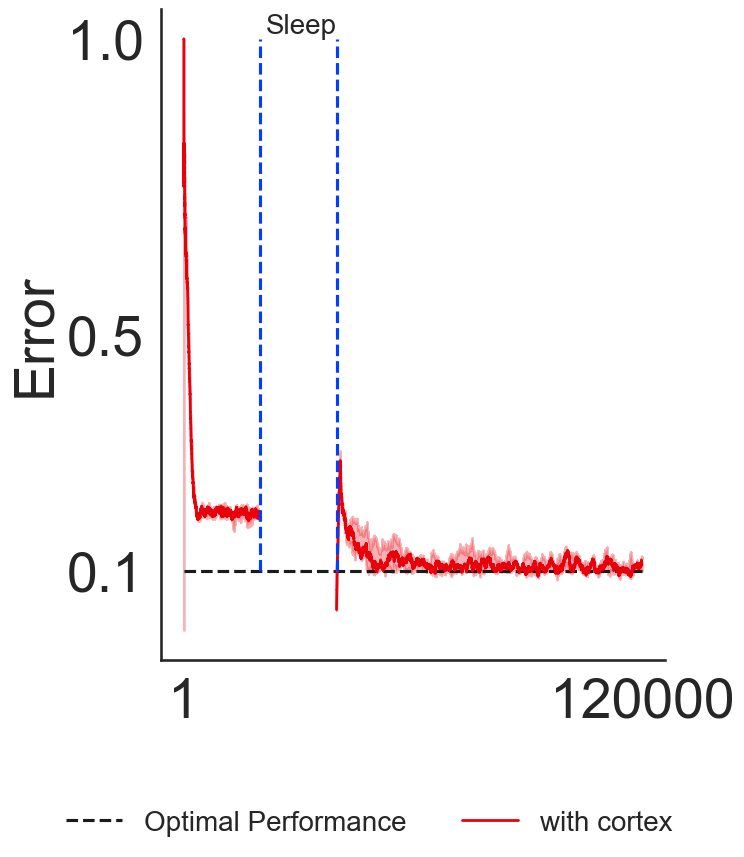

In [105]:
test_acc = np.array(test_acc)
# test_acc_not_sparse = np.array(test_acc_not_sparse)
# test_acc_control = np.array(test_acc_control)
sleep_break = 20000
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

ax.hlines(0.1, 0, total_samples+sleep_break, linestyles='dashed', label='Optimal Performance', color='k')

ax.plot(np.median(1-test_acc[:,:initial_training_sample],axis=0),linewidth=2, color='r', label='with cortex')
ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc[:,:initial_training_sample], 0.75, axis=0), color='r', alpha=.3)

ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc[0][initial_training_sample+sleep_samples:])), np.median(1-test_acc[:,initial_training_sample+sleep_samples:],axis=0),linewidth=2, color='r')
ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc[0][initial_training_sample+sleep_samples:])), np.quantile(1-test_acc[:,initial_training_sample+sleep_samples:], 0.25, axis=0), np.quantile(1-test_acc[:,initial_training_sample+sleep_samples:], 0.75, axis=0), color='r', alpha=.3)


# ax.plot(np.median(1-test_acc_not_sparse[:,:initial_training_sample],axis=0),linewidth=2, color='b', label='with cortex no sparsity')
# ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc_not_sparse[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc_not_sparse[:,:initial_training_sample], 0.75, axis=0), color='b', alpha=.3)

# ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_not_sparse[0][initial_training_sample+sleep_samples:])), np.median(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:],axis=0),linewidth=2, color='b')
# ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_not_sparse[0][initial_training_sample+sleep_samples:])), np.quantile(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:], 0.25, axis=0), np.quantile(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:], 0.75, axis=0), color='b', alpha=.3)

ax.vlines(initial_training_sample, 0.1, 1, linestyles='dashed', color='b')
ax.vlines(initial_training_sample+sleep_break, 0.1, 1, linestyles='dashed', color='b')


# ax.plot(np.median(1-test_acc_control[:,:initial_training_sample],axis=0),linewidth=2, color='k', label='without cortex')
# ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.75, axis=0), color='k', alpha=.3)

# ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_control[0][initial_training_sample:])), np.median(1-test_acc_control[:,initial_training_sample:],axis=0),linewidth=2, color='k')
# ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_control[0][initial_training_sample:])), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.25, axis=0), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.75, axis=0), color='k', alpha=.3)


plt.xticks([1, total_samples+sleep_break])
plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)
# ax.set_yscale('log') 


ax.tick_params(labelsize=40)
    
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

fig.text(.37, .92, 'Sleep', rotation=0, fontsize=20)
fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)
plt.tight_layout()
